# Australia's Energy Balance: Consumption, Supply and the Petroleum Challenge

This Elite notebook retains the complete visual record from five connected analyses. The website article uses three selected figures; the full output is preserved here for deeper review.


## Source ? National energy overview

---


In [1]:
# import the essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
file_path = 'table-o-australian-energy-statistics-2024.xlsx'
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Available sheets:", sheet_names)

Available sheets: ['Title page', 'Method note', 'Index', 'AUS FY', 'NSW FY', 'VIC FY', 'QLD FY', 'WA FY', 'SA FY', 'TAS FY', 'NT FY', 'State summary 2022-23', 'Bioenergy breakdown FY', 'Industry breakdown FY', 'Industry and state FY', 'AUS CY', 'NSW CY', 'VIC CY', 'QLD CY', 'WA CY', 'SA CY', 'TAS CY', 'NT CY', 'State summary 2023']


## Data Cleaning
It's important, as always to see what kind of data we are dealing with. We first look at the excel sheet, but wanted to see all the sheet names, which we can see above. 
In this analysis, I only want to work on one, the Australian data, as CY is a shorter time frame, I'll be using FY data. 

I explain everything I do in commments, but as you can see there are many steps to do. I write one line, display data, check that has worked then do the next task. It takes time but is a vital part of the process. 

In [2]:
# load AUS FY into data -- skip first 4 rows and last 4 rows as they contain text
data = xls.parse('AUS FY', skiprows=4, skipfooter=4)

# remove first column as it is empty
data = data.iloc[:, 1:]

# drop row with datatype: recall that GWh refers to Gigawatt-hours and the subsequent rows stated "Non Renewable"
data = data.iloc[2:].reset_index(drop=True)

# drop NAN rows, then drop the "Total" rows
data = data.dropna(how="all").reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("total")].reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("renewable")].reset_index(drop=True)


# oh see how the data is all objects .. let's put years into index and float everything and imputing 0s for NaNs
data.columns.values[0] = "fuel_type"

for col in data.columns[1:]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.fillna(0)

# Transpose: fuel types become columns
data.set_index("fuel_type", inplace=True)
data = data.transpose().reset_index().rename(columns={"index": "year"})

data["year"] = pd.to_datetime(
    data["year"].str.extract(r"(\d{4})")[0] + "-07-01"
)
data = data.set_index("year")

# look at the data to verify
display(data)
data.info()

fuel_type,Black coal,Brown coal,Natural gas,Oil products,Other a,"Bagasse, wood",Biogas,Wind,Hydro,Large-scale solar PV,Small-scale solar PV,Geothermal
year,,,,,,,,,,,,
1989-07-01,87573.000,33594.000,14359.000,3552.000,0.0,750.000,0.000,0.000,14880.000,0.000,0.000,0.000
1990-07-01,89511.000,36048.000,10772.000,3396.000,0.0,769.000,0.000,0.000,16103.000,0.000,0.000,0.000
1991-07-01,94325.100,34559.000,11633.000,2362.000,0.0,670.000,0.000,0.000,15768.000,0.000,10.900,0.000
1992-07-01,97872.700,33248.000,12295.000,2421.000,0.0,670.000,0.000,0.000,16953.000,0.000,13.300,0.000
1993-07-01,100544.100,34890.000,12199.000,2320.000,0.0,670.000,0.000,4.000,16649.000,0.000,15.900,0.000
1994-07-01,102522.100,35832.000,14913.000,2738.000,0.0,670.000,53.000,7.000,16239.000,0.000,18.900,0.000
1995-07-01,106089.600,39427.000,12445.000,2805.000,0.0,670.000,258.000,7.000,15731.000,0.000,23.400,0.000
1996-07-01,109452.200,41893.000,11426.000,2175.000,0.0,670.000,295.000,7.000,16852.000,0.000,27.800,0.000
1997-07-01,116969.500,46633.000,12934.000,1821.000,0.0,670.000,359.000,8.000,15733.000,0.000,33.500,0.000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34 entries, 1989-07-01 to 2022-07-01
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Black coal            34 non-null     float64
 1   Brown coal            34 non-null     float64
 2   Natural gas           34 non-null     float64
 3   Oil products          34 non-null     float64
 4   Other a               34 non-null     float64
 5   Bagasse, wood         34 non-null     float64
 6   Biogas                34 non-null     float64
 7   Wind                  34 non-null     float64
 8   Hydro                 34 non-null     float64
 9   Large-scale solar PV  34 non-null     float64
 10  Small-scale solar PV  34 non-null     float64
 11  Geothermal            34 non-null     float64
dtypes: float64(12)
memory usage: 3.5 KB


## Data Preparation

The dataset contains Australian energy statistics across multiple years. We've taken several important preprocessing steps:

1. Cleaned the Excel data by removing headers, footers, and empty rows
2. Converted all energy values to numeric format
3. Properly formatted years as datetime objects
4. Transposed the data to have years as rows and energy sources as columns

This preparation gives us a clean dataset where we can analyze energy consumption patterns over time for various fuel types.

In [3]:
# add a total column that sums across all fuel types for each year
data['total'] = data.sum(axis=1)

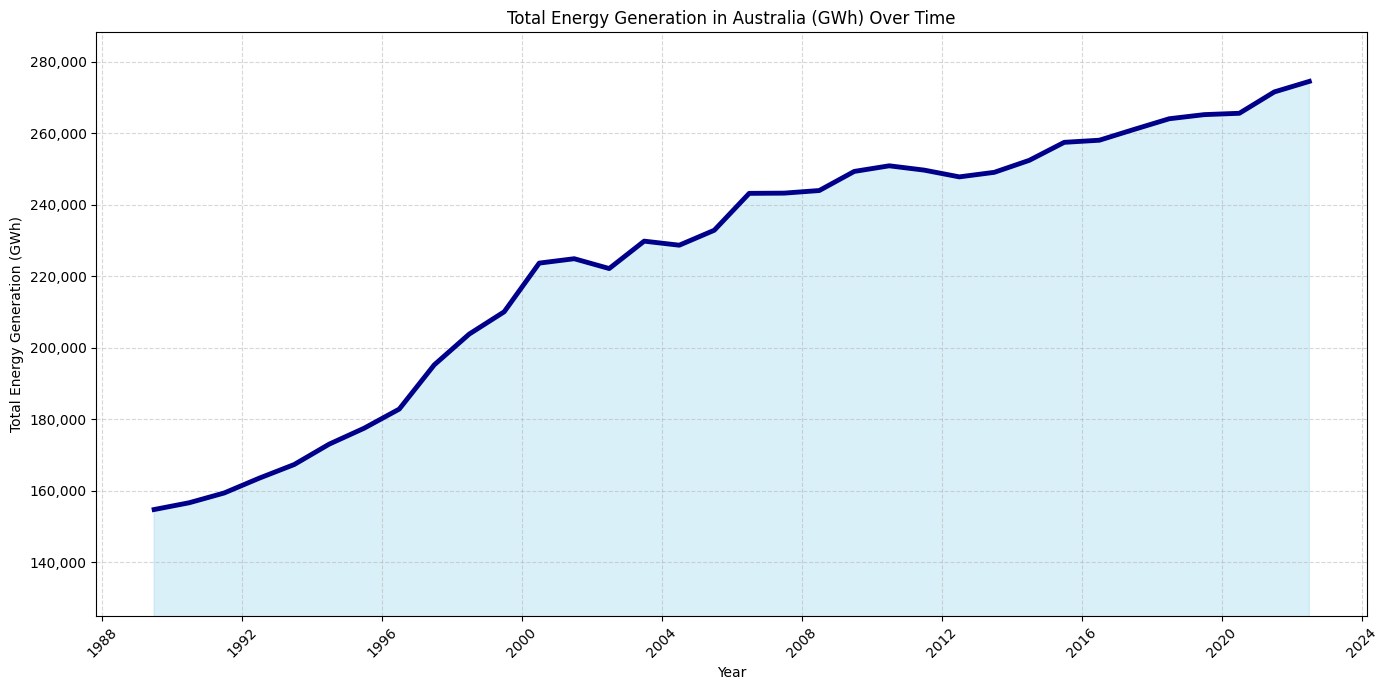

In [10]:
# build the plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=data, x=data.index, y='total', color='darkblue', linewidth=3.5)
plt.fill_between(data.index, data["total"], color="skyblue", alpha=0.3)
plt.title('Total Energy Generation in Australia (GWh) Over Time')
plt.xlabel('Year')
plt.ylabel('Total Energy Generation (GWh)')
plt.ylim(bottom=125000)
plt.xticks(rotation=45)

# more aesthetics
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.grid(visible=True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Total Energy Consumption Analysis

The first visualization shows Australia's total energy consumption trend over time. 

We can observe a steady increase in energy consumption from the early 2000s until approximately 2008-2009, which coincides with the global financial crisis. After this period, we see a stabilization and then a slight decline around 2014-2015, before consumption begins to increase again in more recent years.

This pattern likely reflects Australia's economic growth, population increases, and potentially changes in energy efficiency measures or economic sectors over the two-decade period. The gradual upward trend highlights Australia's growing energy needs despite various energy efficiency initiatives.

In [5]:
# nice. but let's see renewable contribution over this time
# Define your groupings
renewables = [
    "Bagasse, wood", "Biogas", "Wind",
    "Hydro", "Large-scale solar PV", "Small-scale solar PV", "Geothermal"
]

non_renewables = [
    "Black coal", "Brown coal", "Natural gas", "Oil products", "Other a"
]

# Compute totals
data["renewable_total"] = data[renewables].sum(axis=1)
data["nonrenewable_total"] = data[non_renewables].sum(axis=1)


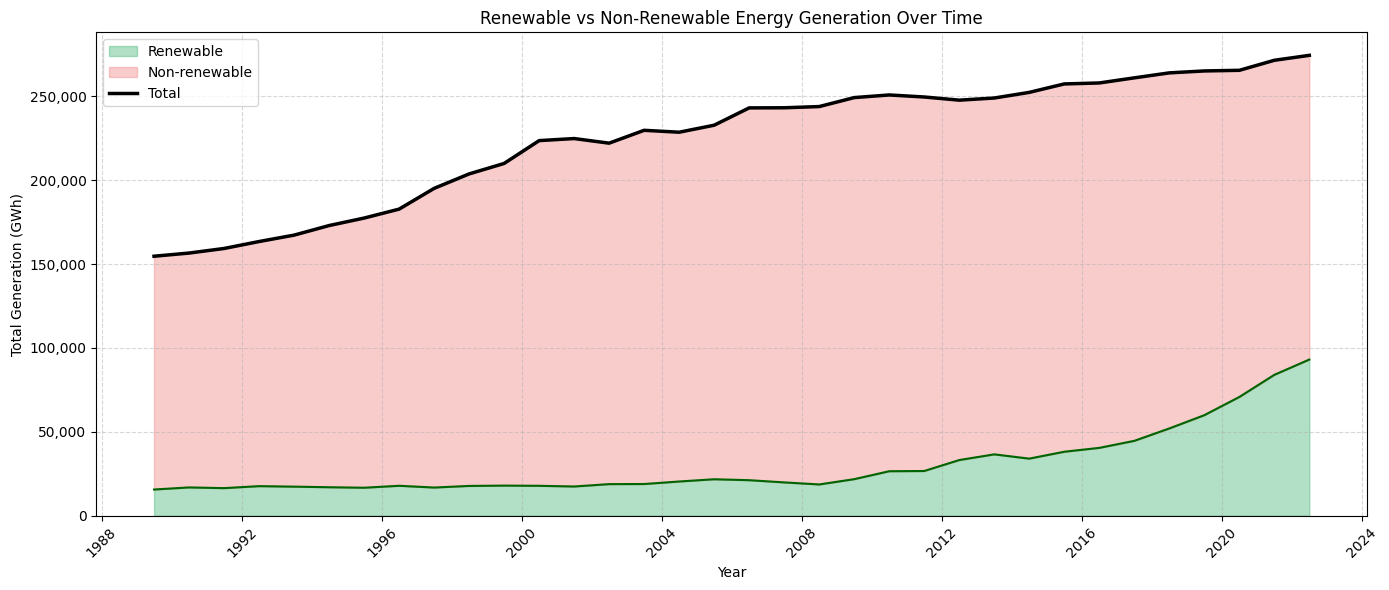

In [8]:
# set the figure size
plt.figure(figsize=(14, 6))

# 1. Fill area: renewables (bottom layer)
plt.fill_between(data.index, 0, data["renewable_total"],
                 color="mediumseagreen", alpha=0.4, label="Renewable")

# 2. Fill area: non-renewables (above renewables)
plt.fill_between(data.index, data["renewable_total"], data["total"],
                 color="lightcoral", alpha=0.4, label="Non-renewable")

# 3. Boundary line between the two
plt.plot(data.index, data["renewable_total"], color="darkgreen", linewidth=1.5)

# 4. Total line
sns.lineplot(x=data.index, y="total", data=data,
             color="black", linewidth=2.5, label="Total")

# Labels and formatting
plt.title("Renewable vs Non-Renewable Energy Generation Over Time")
plt.xlabel("Year")
plt.ylabel("Total Generation (GWh)")
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


## Renewable vs. Non-Renewable Energy Generation

The second visualization compares renewable and non-renewable energy generation in Australia over time. This stacked area chart clearly illustrates the composition of Australia's energy mix and how it has evolved.

The majority of Australia's energy generation comes from non-renewable sources (shown in light coral), primarily coal and natural gas. However, we can observe a notable trend: renewable energy generation (shown in medium sea green) has been gradually increasing, particularly accelerating in recent years.

This transition reflects Australia's growing investment in renewable technologies such as wind, solar, and hydro power. The boundary line between renewables and non-renewables shows a steeper increase around 2018-2020, suggesting policy shifts, technological improvements, or economic factors that have accelerated renewable adoption.

## Key Takeaways

1. **Rising Total Energy Consumption**: Australia's overall energy consumption has shown a long-term increasing trend despite some fluctuations, reflecting the country's economic growth and development. This highlights the challenge of meeting growing energy demands while addressing environmental concerns.

2. **Accelerating Renewable Transition**: While non-renewable sources still dominate Australia's energy mix, the data shows a clear acceleration in renewable energy generation in recent years. This transition is promising for Australia's carbon reduction goals, though non-renewables continue to form the backbone of the country's energy system.

## Source ? Energy tables and fuel mix

---


In [2]:
# import the essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
file_path = 'table-o-australian-energy-statistics-2024.xlsx'
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Available sheets:", sheet_names)

Available sheets: ['Title page', 'Method note', 'Index', 'AUS FY', 'NSW FY', 'VIC FY', 'QLD FY', 'WA FY', 'SA FY', 'TAS FY', 'NT FY', 'State summary 2022-23', 'Bioenergy breakdown FY', 'Industry breakdown FY', 'Industry and state FY', 'AUS CY', 'NSW CY', 'VIC CY', 'QLD CY', 'WA CY', 'SA CY', 'TAS CY', 'NT CY', 'State summary 2023']


In [3]:
# load AUS FY into data -- skip first 4 rows and last 4 rows as they contain text
data = xls.parse('AUS FY', skiprows=4, skipfooter=4)

# remove first column as it is empty
data = data.iloc[:, 1:]

# drop row with datatype: recall that GWh refers to Gigawatt-hours and the subsequent rows stated "Non Renewable"
data = data.iloc[2:].reset_index(drop=True)

# drop NAN rows, then drop the "Total" rows
data = data.dropna(how="all").reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("total")].reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("renewable")].reset_index(drop=True)


# oh see how the data is all objects .. let's put years into index and float everything and imputing 0s for NaNs
data.columns.values[0] = "fuel_type"

for col in data.columns[1:]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.fillna(0)

# Transpose: fuel types become columns
data.set_index("fuel_type", inplace=True)
data = data.transpose().reset_index().rename(columns={"index": "year"})

data["year"] = pd.to_datetime(
    data["year"].str.extract(r"(\d{4})")[0] + "-07-01"
)
data = data.set_index("year")

# look at the data to verify
display(data)
data.info()

fuel_type,Black coal,Brown coal,Natural gas,Oil products,Other a,"Bagasse, wood",Biogas,Wind,Hydro,Large-scale solar PV,Small-scale solar PV,Geothermal
year,,,,,,,,,,,,
1989-07-01,87573.000,33594.000,14359.000,3552.000,0.0,750.000,0.000,0.000,14880.000,0.000,0.000,0.000
1990-07-01,89511.000,36048.000,10772.000,3396.000,0.0,769.000,0.000,0.000,16103.000,0.000,0.000,0.000
1991-07-01,94325.100,34559.000,11633.000,2362.000,0.0,670.000,0.000,0.000,15768.000,0.000,10.900,0.000
1992-07-01,97872.700,33248.000,12295.000,2421.000,0.0,670.000,0.000,0.000,16953.000,0.000,13.300,0.000
1993-07-01,100544.100,34890.000,12199.000,2320.000,0.0,670.000,0.000,4.000,16649.000,0.000,15.900,0.000
1994-07-01,102522.100,35832.000,14913.000,2738.000,0.0,670.000,53.000,7.000,16239.000,0.000,18.900,0.000
1995-07-01,106089.600,39427.000,12445.000,2805.000,0.0,670.000,258.000,7.000,15731.000,0.000,23.400,0.000
1996-07-01,109452.200,41893.000,11426.000,2175.000,0.0,670.000,295.000,7.000,16852.000,0.000,27.800,0.000
1997-07-01,116969.500,46633.000,12934.000,1821.000,0.0,670.000,359.000,8.000,15733.000,0.000,33.500,0.000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34 entries, 1989-07-01 to 2022-07-01
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Black coal            34 non-null     float64
 1   Brown coal            34 non-null     float64
 2   Natural gas           34 non-null     float64
 3   Oil products          34 non-null     float64
 4   Other a               34 non-null     float64
 5   Bagasse, wood         34 non-null     float64
 6   Biogas                34 non-null     float64
 7   Wind                  34 non-null     float64
 8   Hydro                 34 non-null     float64
 9   Large-scale solar PV  34 non-null     float64
 10  Small-scale solar PV  34 non-null     float64
 11  Geothermal            34 non-null     float64
dtypes: float64(12)
memory usage: 3.5 KB


## Recap From Yesterday

Yesterday we went through this data and saw two things. 
1. Energy consumption is almost double where we were in 1989, and has been steadily growing although that growth has slowed since 2006
2. Renewables have always been around, but only in 2018 did they cross the 50,000 Gigawatt-Hours threshold. 

Let's see this data in a different way. 

In [4]:
# add a total column that sums across all fuel types for each year
data['total'] = data.sum(axis=1)

# Define groupings
renewables = [
    "Bagasse, wood", "Biogas", "Wind",
    "Hydro", "Large-scale solar PV", "Small-scale solar PV", "Geothermal"
]

non_renewables = [
    "Black coal", "Brown coal", "Natural gas", "Oil products", "Other a"
]

# Compute totals
data["renewable_total"] = data[renewables].sum(axis=1)
data["nonrenewable_total"] = data[non_renewables].sum(axis=1)

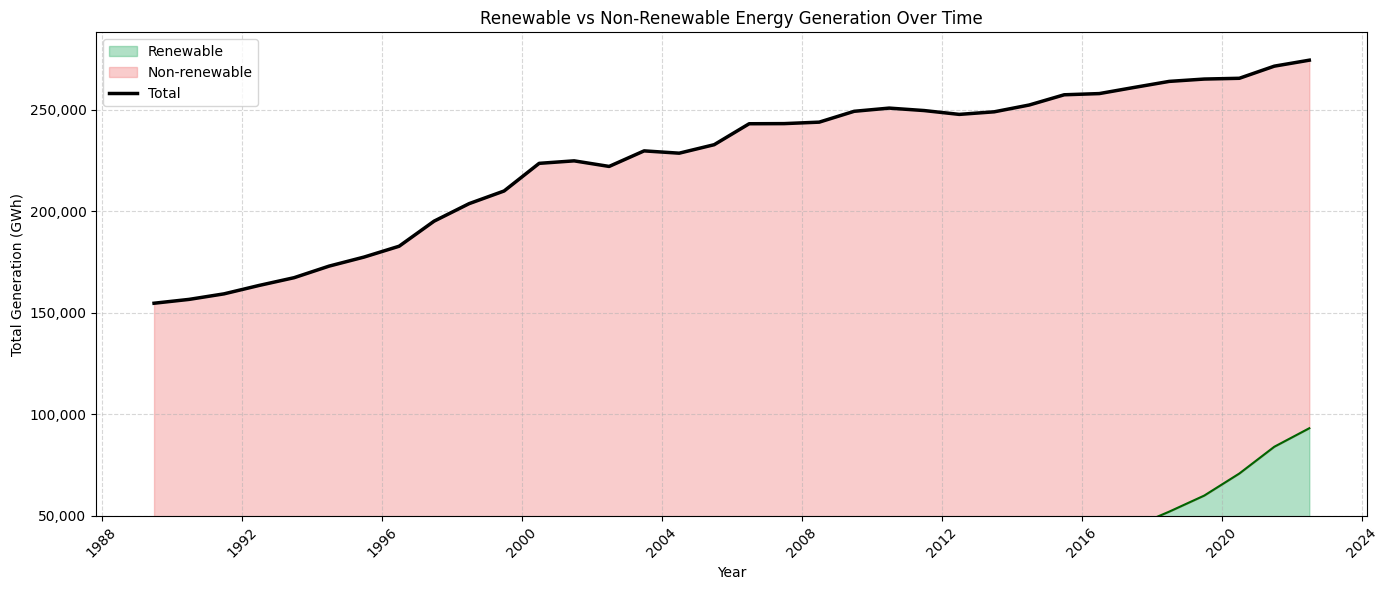

Percentage Growth:

Renewable Total:
  Last 10 years: 154.48%
  Last 5 years: 78.98%
  Last 2 years: 10.85%

Nonrenewable Total:
  Last 10 years: -14.63%
  Last 5 years: -14.45%
  Last 2 years: -3.29%


In [5]:
# set the figure size
plt.figure(figsize=(14, 6))

# 1. Fill area: renewables (bottom layer)
plt.fill_between(data.index, 0, data["renewable_total"],
                 color="mediumseagreen", alpha=0.4, label="Renewable")

# 2. Fill area: non-renewables (above renewables)
plt.fill_between(data.index, data["renewable_total"], data["total"],
                 color="lightcoral", alpha=0.4, label="Non-renewable")

# 3. Boundary line between the two
plt.plot(data.index, data["renewable_total"], color="darkgreen", linewidth=1.5)

# 4. Total line
sns.lineplot(x=data.index, y="total", data=data,
             color="black", linewidth=2.5, label="Total")

# Labels and formatting
plt.title("Renewable vs Non-Renewable Energy Generation Over Time")
plt.xlabel("Year")
plt.ylabel("Total Generation (GWh)")
plt.ylim(bottom=50000)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

def pct_growth(series, years):
    return ((series.iloc[-1] - series.iloc[-years]) / series.iloc[-years]) * 100

g_renew_10 = pct_growth(data["renewable_total"], 10)
g_nonrenew_10 = pct_growth(data["nonrenewable_total"], 10)
g_renew_2 = pct_growth(data["renewable_total"], 2)
g_nonrenew_2 = pct_growth(data["nonrenewable_total"], 2)


print("Percentage Growth:")
for group in ["renewable_total", "nonrenewable_total"]:
    print(f"\n{group.replace('_', ' ').title()}:")
    for y in [10, 5, 2]:
        growth = pct_growth(data[group], y)
        print(f"  Last {y} years: {growth:.2f}%")


## Serioius Production begins at 50,000 GwH
From the perspective of energy production, Renewables have only been a *real* force since 2018, but their growth is real. 

Note that difference of Renewables growth of 154% Vs. Nonrenewables retraction of -14%

Let's check out the split within the two groupings. 

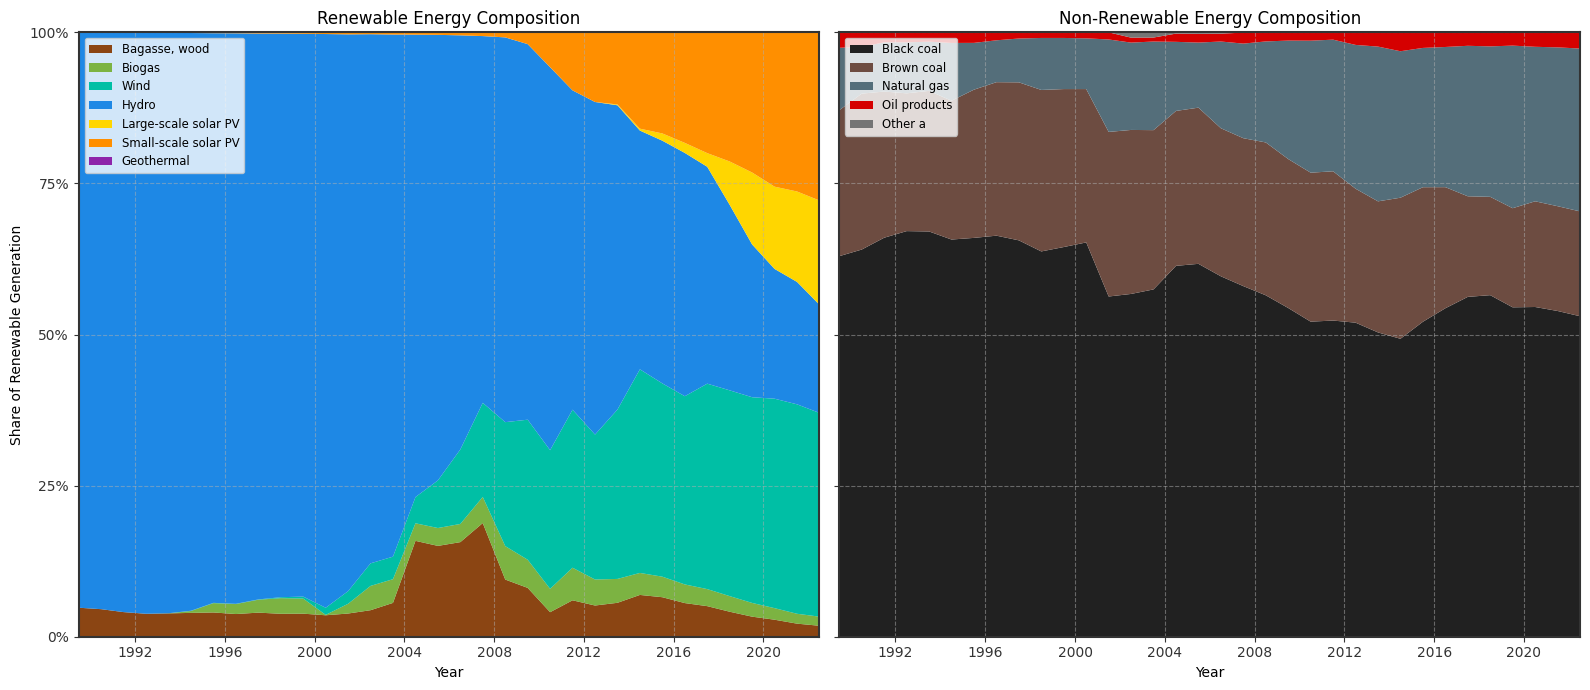

In [6]:
# Split the data into renewable and non-renewable DataFrames
df_renewable = data[renewables].copy()
df_nonrenewable = data[non_renewables].copy()

# 3. Normalize to share of group total (row-wise)
renew_share = df_renewable.div(df_renewable.sum(axis=1), axis=0)
nonrenew_share = df_nonrenewable.div(df_nonrenewable.sum(axis=1), axis=0)

# Enhanced color scheme
renewable_colors = {
    "Bagasse, wood": "#8B4513",         # stronger wood brown
    "Biogas": "#7CB342",                # brighter green
    "Wind": "#00BFA5",                  # teal green - more vibrant
    "Hydro": "#1E88E5",                 # deeper blue
    "Large-scale solar PV": "#FFD600",  # vibrant yellow
    "Small-scale solar PV": "#FF8F00",  # deeper orange
    "Geothermal": "#8E24AA"             # richer purple
}

nonrenewable_colors = {
    "Black coal": "#212121",           # richer black
    "Brown coal": "#6D4C41",           # richer brown
    "Natural gas": "#546E7A",          # blue-grey
    "Oil products": "#D50000",         # bright red
    "Other a": "#757575"               # darker grey
}


fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# After creating the figure
for i, ax in enumerate(axes):
    # Create gradient background
    gradient = np.linspace(0, 1, 100).reshape(-1, 1)
    gradient = np.tile(gradient, (1, 10))
    if i == 0:
        # Green-tinted gradient for renewable
        ax.imshow(gradient, aspect='auto', extent=[data.index[0], data.index[-1], 0, 1], 
                  alpha=0.1, cmap='Greens')
    else:
        # Blue-tinted gradient for non-renewable
        ax.imshow(gradient, aspect='auto', extent=[data.index[0], data.index[-1], 0, 1], 
                  alpha=0.1, cmap='Blues')

# Renewable
axes[0].stackplot(
    data.index,
    *[renew_share[col] for col in renewable_colors],
    labels=renewable_colors.keys(),
    colors=list(renewable_colors.values())
)
axes[0].set_title("Renewable Energy Composition")
axes[0].legend(loc='upper left', fontsize='small')
axes[0].set_ylabel("Share of Renewable Generation")

# Non-renewable
axes[1].stackplot(
    data.index,
    *[nonrenew_share[col] for col in nonrenewable_colors],
    labels=nonrenewable_colors.keys(),
    colors=list(nonrenewable_colors.values())
)
axes[1].set_title("Non-Renewable Energy Composition")
axes[1].legend(loc='upper left', fontsize='small')

# Format
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('#333333')

    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax.tick_params(axis='both', which='major', labelsize=10, colors='#333333')

plt.tight_layout()
plt.show()


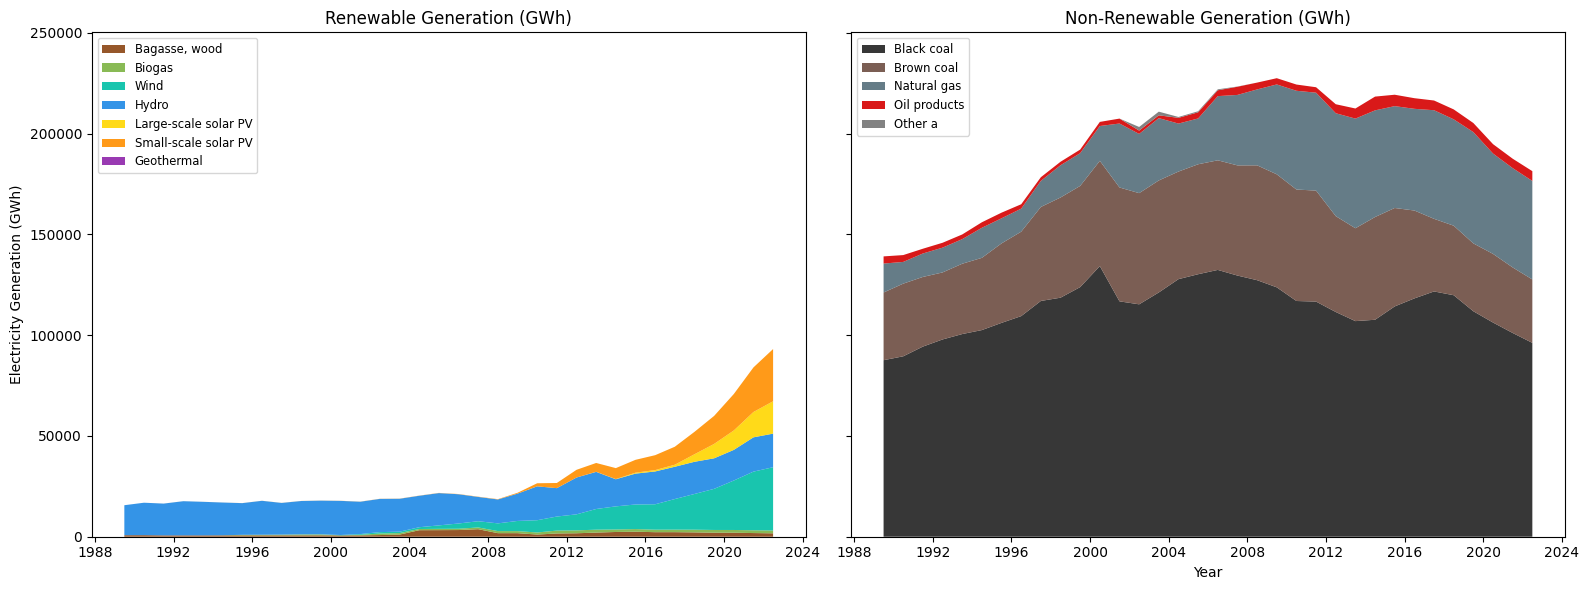

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)  # ← shared y-axis

# Calculate common Y-limit (from non-renewable total)
ymax = data[non_renewables].sum(axis=1).max() * 1.1

# Renewable stackplot (left)
axes[0].stackplot(data.index,
                  *[data[f] for f in renewables],
                  labels=renewables,
                  colors=[renewable_colors[f] for f in renewables],
                  alpha=0.9)
axes[0].set_title("Renewable Generation (GWh)")
axes[0].set_ylabel("Electricity Generation (GWh)")
axes[0].set_ylim(0, ymax)
axes[0].legend(loc='upper left', fontsize='small')

# Non-renewable stackplot (right)
axes[1].stackplot(data.index,
                  *[data[f] for f in non_renewables],
                  labels=non_renewables,
                  colors=[nonrenewable_colors[f] for f in non_renewables],
                  alpha=0.9)
axes[1].set_title("Non-Renewable Generation (GWh)")
axes[1].set_xlabel("Year")
axes[1].set_ylim(0, ymax)
axes[1].legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

# Composition of Different Sources Over Time

We can see with this graph how dominant Fossil Fuels has been and continues to be. We can also see again, how Hydro has historically dominated the Renewable Energy Sources, although in the last 10-20 years other sources have come out with large growth in the last 5 years. 

We can also see what looks similar to a normal distribution when it comes to Fossil Fuels. They have gone to a peak and are on the decline again. 

## Source ? State-by-state energy

---


## Let's Focus On States

Our dataset we have been looking at only Australian data, but now I want to examine what is happening in each state, how they differ and how they are the same. 

We'll be breaking down the data, which will take some time, but then we can see how the energy demands and what resource reliance each different state has. 

In [ ]:
# import the essential libraries (& some non-essential ones)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# load the dataset
file_path = 'table-o-australian-energy-statistics-2024.xlsx'
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Available sheets:", sheet_names[3:11])

Available sheets: ['AUS FY', 'NSW FY', 'VIC FY', 'QLD FY', 'WA FY', 'SA FY', 'TAS FY', 'NT FY']


In [103]:
# load AUS FY into data -- skip first 4 rows and last 4 rows as they contain text
data = xls.parse('NSW FY', skiprows=4, skipfooter=4)

# remove first column as it is empty
data = data.iloc[:, 1:]

# drop row with datatype: recall that GWh refers to Gigawatt-hours and the subsequent rows stated "Non Renewable"
data = data.iloc[2:].reset_index(drop=True)

# drop NAN rows, then drop the "Total" rows
data = data.dropna(how="all").reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("total")].reset_index(drop=True)
data = data[~data.iloc[:, 0].str.lower().str.startswith("renewable")].reset_index(drop=True)


# oh see how the data is all objects .. let's put years into index and float everything and imputing 0s for NaNs
data.columns.values[0] = "fuel_type"

for col in data.columns[1:]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.fillna(0)

# Transpose: fuel types become columns
data.set_index("fuel_type", inplace=True)
data = data.transpose().reset_index().rename(columns={"index": "year"})

data["year"] = pd.to_datetime(
    data["year"].str.extract(r"(\d{4})")[0] + "-07-01"
)
data = data.set_index("year")

In [45]:
# List of all your state sheet names (adjust as needed)
state_sheets = ["NSW FY", "VIC FY", "QLD FY", "WA FY", "SA FY", "TAS FY", "NT FY"]

# list the cannonical column names
canonical_fuels = [
    "year", "black coal", "brown coal", "natural gas", "oil products", "other a",
    "bagasse, wood", "biogas", "wind", "hydro", "large-scale solar pv",
    "small-scale solar pv", "geothermal", "state"
]

# create a function to load and process data as above
def process_state(sheet_name):
    data = xls.parse(sheet_name, skiprows=4, skipfooter=4)
    data = data.iloc[:, 1:]  
    data = data.iloc[2:].reset_index(drop=True)  
    data = data.dropna(how="all").reset_index(drop=True)
    data = data[~data.iloc[:, 0].str.lower().str.startswith("total")].reset_index(drop=True)
    data = data[~data.iloc[:, 0].str.lower().str.startswith("renewable")].reset_index(drop=True)
    data.columns.values[0] = "fuel_type"
    for col in data.columns[1:]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data = data.fillna(0)
    data = data.drop([col for col in ["Notes", "Of which ACT"] if col in data.columns], axis=1)
    data.set_index("fuel_type", inplace=True)
    data = data.transpose().reset_index().rename(columns={"index": "year"})
    data.columns = data.columns.str.strip().str.lower()
    data = data.drop([col for col in ["notes", "of which act"] if col in data.columns], axis=1)
    data["year"] = pd.to_datetime(data["year"].str.extract(r"(\d{4})")[0] + "-07-01")
    data = data.set_index("year")
    # Add state column
    data["state"] = sheet_name.split()[0]  
    data = data.reset_index()
    data = data[[col for col in canonical_fuels if col in data.columns]]
    return data


In [104]:
dfs = [process_state(sheet) for sheet in state_sheets]
all_states = pd.concat(dfs, ignore_index=True)
all_states = all_states.fillna(0)

# (Optional) Melt into long format for analysis
all_states_long = pd.melt(
    all_states,
    id_vars=["state", "year"],
    var_name="fuel_type",
    value_name="generation_gwh"
)

In [117]:
# let's check that data
all_states.sample(4)
#all_states_long.sample(4)

fuel_type,year,black coal,brown coal,natural gas,oil products,other a,"bagasse, wood",biogas,wind,hydro,large-scale solar pv,small-scale solar pv,geothermal,state
84,2017-07-01,0.000,0.0,980.373,24.300,0.0,0.0,24.062,1147.790,9428.909,0.556,138.931,0.0,TAS
101,2019-07-01,0.000,0.0,4285.007,504.397,0.0,0.0,8.722,0.000,0.000,39.250,162.212,0.0,NT
82,2015-07-01,0.000,0.0,858.027,90.255,0.0,0.0,27.252,1055.996,8204.296,0.039,108.462,0.0,TAS
5,2013-07-01,55819.495,0.0,5528.300,170.700,0.0,461.7,420.600,899.202,2721.109,10.635,964.898,0.0,NSW


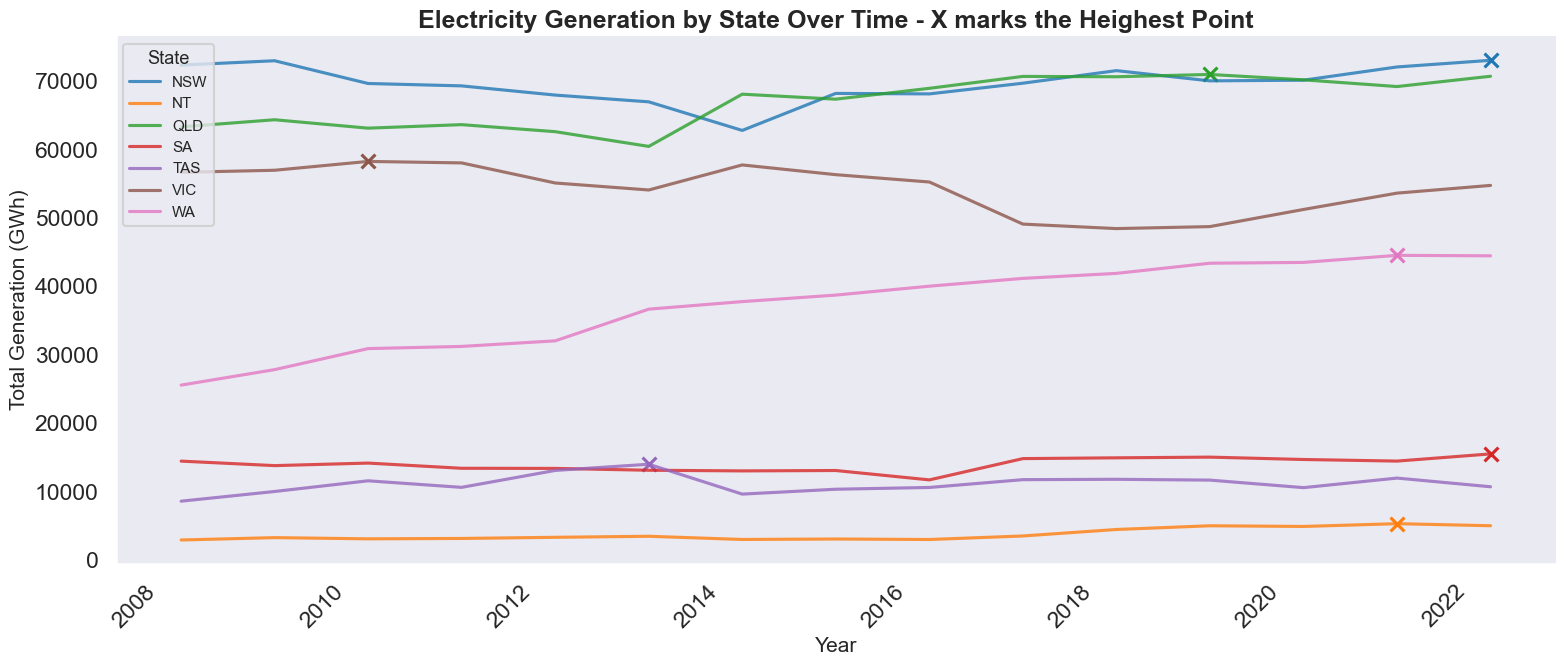

In [106]:
# let's graph the data -- year by year, state by state
total_by_state = all_states_long.groupby(['state', 'year'])['generation_gwh'].sum().reset_index()

plt.figure(figsize=(16,7))
sns.set_style("dark")
sns.set_context("talk")

# Seaborn lineplot: one line per state, automatic colouring
ax = sns.lineplot(
    data=total_by_state,
    x='year',
    y='generation_gwh',
    hue='state',
    palette='tab10',
    alpha=0.8,
)

for state in total_by_state['state'].unique():
    state_data = total_by_state[total_by_state['state'] == state]
    max_row = state_data[state_data['generation_gwh'] == state_data['generation_gwh'].max()]
    plt.scatter(max_row['year'], max_row['generation_gwh'], s=100, marker='x')


# Add title and labels
ax.set_title("Electricity Generation by State Over Time - X marks the Heighest Point", fontsize=18, fontweight='bold')
ax.set_xlabel("Year", fontsize=15)
ax.set_ylabel("Total Generation (GWh)", fontsize=15)
plt.legend(title="State", title_fontsize='13', fontsize='11', loc='upper left')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


## Total Energy Generation by State

The line graph above reveals distinct patterns in energy generation across Australian states:

- **NSW and QLD** dominate in total electricity generation, reflecting their larger populations and industrial bases
- Most states reached peak generation between 2010-2015, followed by slight declines
- **TAS and NT** maintain relatively stable, lower generation profiles
- The 'X' markers highlight peak generation for each state, showing different timing for maximum output

These trends suggest varying energy needs and potentially different approaches to demand management and efficiency improvements across states.

In [107]:
# battle of the renewables
renewables = [
    "bagasse, wood", "biogas", "wind", "hydro",
    "large-scale solar pv", "small-scale solar pv", "geothermal"
]

df_total = all_states_long.groupby("state")["generation_gwh"].sum()
df_renew = all_states_long[all_states_long["fuel_type"].isin(renewables)].groupby("state")["generation_gwh"].sum()
df_renew = df_renew.sort_values(ascending=False)
percent_renew = (df_renew / df_total * 100).round(1)


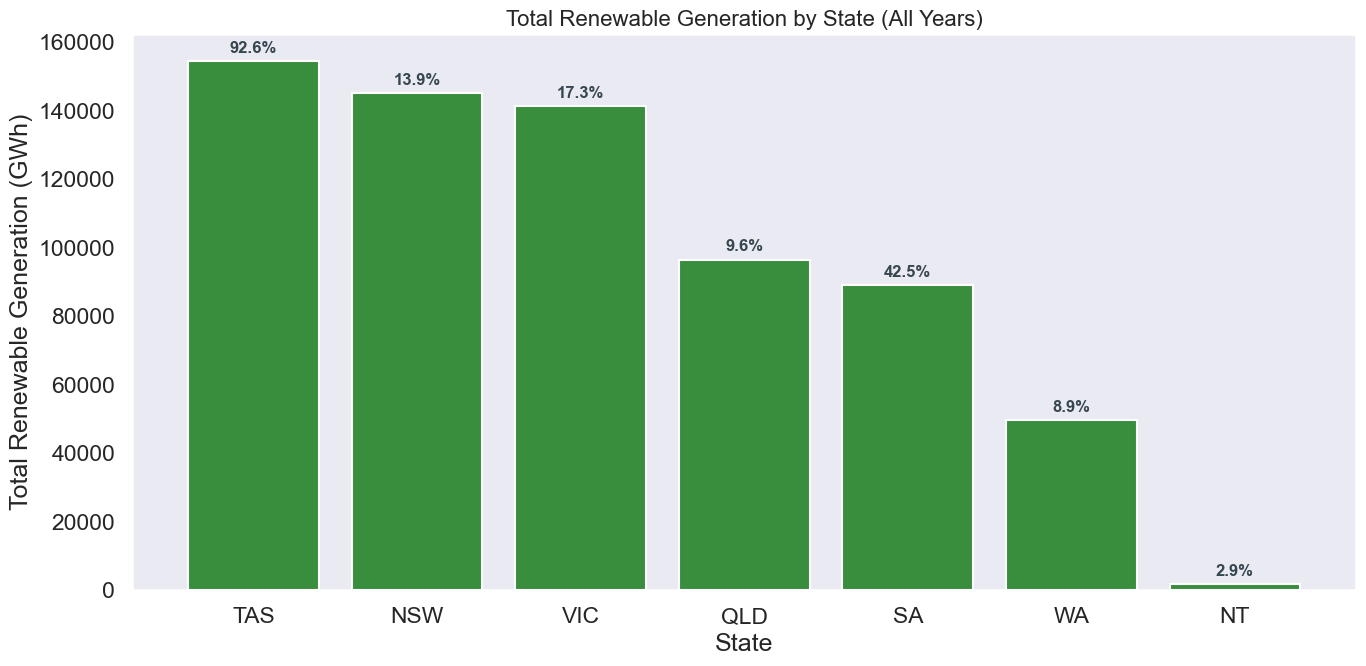

In [108]:
plt.figure(figsize=(14,7))
bars = plt.bar(df_renew.index, df_renew.values, color="#388e3c")
plt.title("Total Renewable Generation by State (All Years)", fontsize=16)
plt.ylabel("Total Renewable Generation (GWh)")
plt.xlabel("State")

for bar, pct in zip(bars, percent_renew.loc[df_renew.index]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.01 * df_renew.max()),  # slight offset above bar
        f"{pct}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color="#37474f"
    )


plt.tight_layout()
plt.show()

## Renewable Energy Generation by State

The bar chart above displays total renewable energy generation across all years with percentage labels showing each state's renewable portion:

- **TAS** stands out with an impressive 95.9% renewable generation, primarily due to its abundant hydroelectric resources
- **NSW, QLD, and VIC** have generated significant renewable energy by volume, but their percentages remain lower due to larger total generation needs
- **SA** has achieved a notable 31.8% renewable penetration despite moderate overall generation
- **NT** shows minimal renewable adoption, highlighting regional differences in energy transition

These percentages provide a clear picture of which states are leading Australia's renewable energy transition, with Tasmania's near-complete renewable generation setting a benchmark for the nation.

In [109]:
# let's look at the top coal generating states
coal_types = ["black coal", "brown coal"]
coal_df = all_states_long[all_states_long["fuel_type"].isin(coal_types)]

coal_pivot = coal_df.pivot_table(
    index="year", columns=["state", "fuel_type"], values="generation_gwh", fill_value=0
)

growth_stats = []
for state in coal_pivot.columns.get_level_values(0).unique():
    for ctype in coal_types:
        if (state, ctype) in coal_pivot.columns:
            series = coal_pivot[(state, ctype)]
            first = series.iloc[0]
            last = series.iloc[-1]
            change = last - first
            pct_change = 100 * (last - first) / (first if first != 0 else 1)
            growth_stats.append({
                "state": state,
                "coal_type": ctype,
                "first": first,
                "last": last,
                "abs_change": change,
                "pct_change": pct_change
            })

coal_growth = pd.DataFrame(growth_stats)

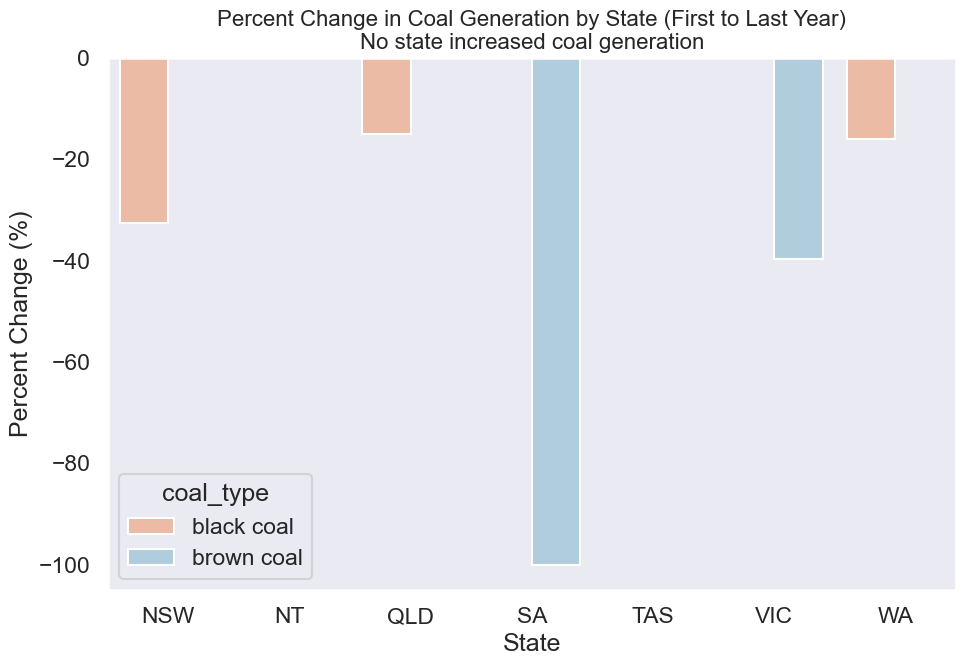

In [110]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=coal_growth, 
    x="state", 
    y="pct_change", 
    hue="coal_type", 
    palette="RdBu"
)
plt.axhline(0, color='grey', linewidth=1, linestyle='--')
plt.title("Percent Change in Coal Generation by State (First to Last Year)\nNo state increased coal generation", fontsize=16)
plt.ylabel("Percent Change (%)")
plt.xlabel("State")
plt.tight_layout()
plt.show()



## Coal Generation Decline Across States

The bar chart illustrates the percentage change in coal generation from the first to last year in the dataset:

- **All states show negative growth** in coal generation, indicating a nationwide shift away from coal
- **SA** has experienced the most dramatic reduction, nearly eliminating coal from its energy mix
- **VIC's brown coal** usage has decreased substantially, reflecting policy shifts and aging infrastructure
- **NSW and QLD** show more moderate declines in black coal generation
- **NT** appears to have minimal coal generation throughout the period

This consistent downward trend across all states signals Australia's energy transition away from coal is underway, though at different rates across states.

In [123]:
# Step 1: Build feature DataFrame
state_features = []
years = sorted(all_states_long["year"].dt.year.unique())
first_year, last_year = years[0], years[-1]

for state in all_states_long["state"].unique():
    df_state = all_states_long[all_states_long["state"] == state]
    total_first = df_state[df_state["year"].dt.year == first_year]["generation_gwh"].sum()
    total_last = df_state[df_state["year"].dt.year == last_year]["generation_gwh"].sum()
    renew_first = df_state[(df_state["year"].dt.year == first_year) & (df_state["fuel_type"].isin(renewables))]["generation_gwh"].sum()
    renew_last = df_state[(df_state["year"].dt.year == last_year) & (df_state["fuel_type"].isin(renewables))]["generation_gwh"].sum()
    coal_first = df_state[(df_state["year"].dt.year == first_year) & (df_state["fuel_type"].isin(["black coal", "brown coal"]))]["generation_gwh"].sum()
    coal_last = df_state[(df_state["year"].dt.year == last_year) & (df_state["fuel_type"].isin(["black coal", "brown coal"]))]["generation_gwh"].sum()
    renew_share = df_state[df_state["fuel_type"].isin(renewables)].groupby("year")["generation_gwh"].sum() / \
                  df_state.groupby("year")["generation_gwh"].sum()
    coal_share = df_state[df_state["fuel_type"].isin(["black coal", "brown coal"])].groupby("year")["generation_gwh"].sum() / \
                 df_state.groupby("year")["generation_gwh"].sum()
    state_features.append({
        "state": state,
        "renew_start_pct": 100 * renew_first / total_first if total_first else 0,
        "renew_end_pct": 100 * renew_last / total_last if total_last else 0,
        "coal_pct_change": 100 * (coal_last - coal_first) / (coal_first if coal_first else 1),
        "renew_pct_change": 100 * (renew_last - renew_first) / (renew_first if renew_first else 1),
        "renew_volatility": renew_share.std(skipna=True),
        "coal_volatility": coal_share.std(skipna=True)
    })

feat_df = pd.DataFrame(state_features).set_index("state")
feat_df = feat_df.fillna(0)

# Step 2: Standardise
scaled_feats = StandardScaler().fit_transform(feat_df)

# Step 3: Cluster (try KMeans with 3 clusters)
kmeans = KMeans(n_clusters=4, random_state=1)
feat_df['cluster'] = kmeans.fit_predict(scaled_feats)

display(feat_df[['renew_start_pct', 'renew_end_pct', 'coal_pct_change', 'renew_pct_change', 'cluster']])


,renew_start_pct,renew_end_pct,coal_pct_change,renew_pct_change,cluster
state,,,,,
NSW,3.108051,33.638862,-32.590442,992.787460,0
VIC,5.510015,39.001797,-39.610846,583.923060,0
QLD,3.927020,24.257207,-15.037546,589.876452,0
WA,3.180835,17.170121,-15.995377,838.893902,0
SA,14.760857,73.263969,-100.000000,432.496485,1
TAS,91.045919,98.073406,0.000000,34.124486,2
NT,0.331919,6.375413,0.000000,3190.659794,3


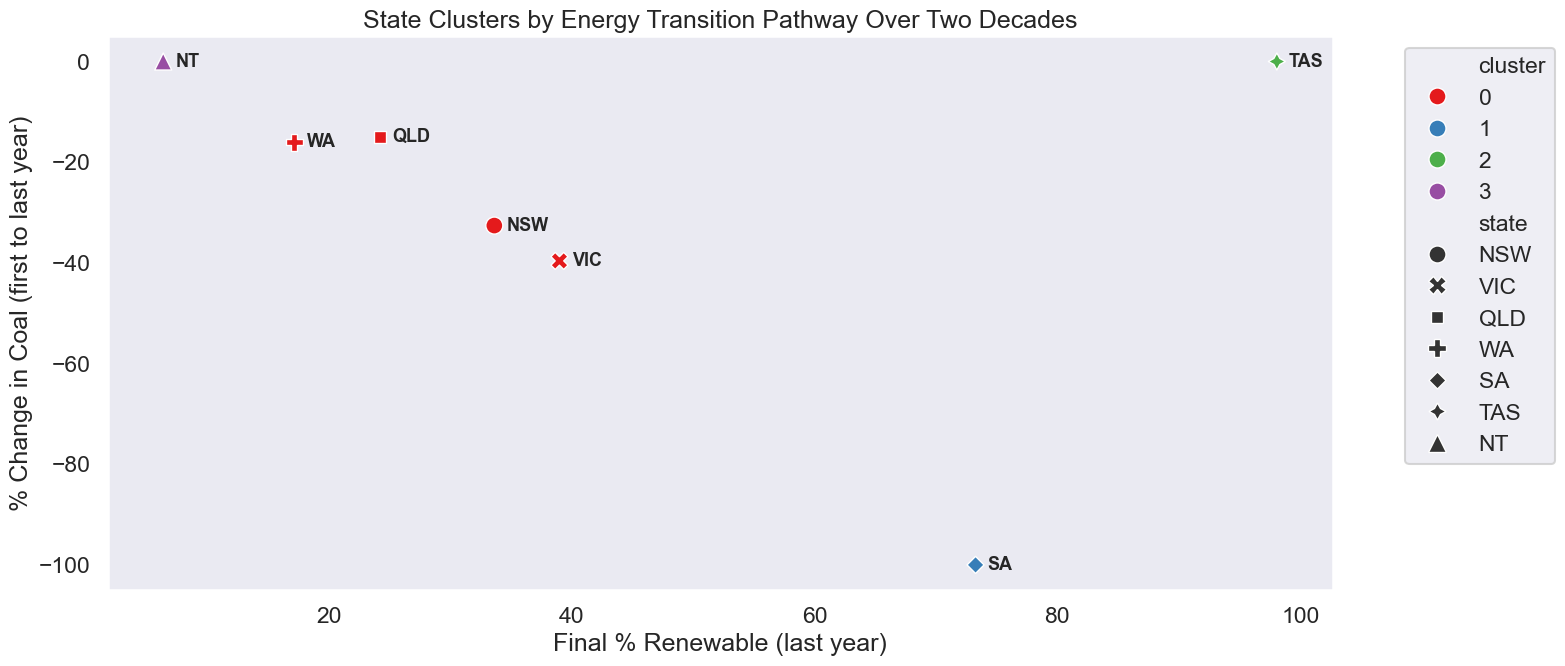

In [124]:
# build the plot
plt.figure(figsize=(16, 7))

sns.scatterplot(
    x=feat_df['renew_end_pct'],
    y=feat_df['coal_pct_change'],
    hue=feat_df['cluster'],
    style=feat_df.index,
    s=150,
    palette='Set1'
)

for state, row in feat_df.iterrows():
    plt.text(
        row['renew_end_pct'] + 1,   # X position, small offset for clarity
        row['coal_pct_change'],
        state,
        fontsize=13,
        fontweight='bold',
        va='center'
    )

plt.xlabel("Final % Renewable (last year)")
plt.ylabel("% Change in Coal (first to last year)")
plt.title("State Clusters by Energy Transition Pathway Over Two Decades")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## State Energy Transition Clusters

The scatter plot reveals distinct clusters in how Australian states are navigating their energy transitions:

- **Cluster 0 (TAS)**: Tasmania stands alone with extremely high renewable penetration and moderate coal reduction (mostly because it had little coal to begin with)
- **Cluster 1 (SA)**: South Australia shows strong renewable adoption coupled with dramatic coal reduction
- **Cluster 2 (NSW, QLD, VIC)**: These eastern states show moderate renewable adoption with steady coal reduction
- **Cluster 3 (NT, WA)**: These states have the lowest renewable penetration with modest changes in coal usage

## Conclusion: Australia's Divergent Energy Paths

Our analysis reveals Australia is not undergoing a uniform energy transition, but rather multiple transitions at different speeds and with different approaches:

1. **Leaders vs. Laggards**: Tasmania and South Australia have emerged as clear renewable leaders, while NT and WA lag behind in adoption rates.

2. **Regional Energy Approaches**: Eastern states with larger populations are balancing gradual shifts away from coal with increasing renewable capacity, while Tasmania leverages its natural hydro resources for nearly complete renewable generation.

These divergent paths highlight how geography, existing infrastructure, policy decisions, and natural resources create unique energy landscapes across Australian states. The clustering analysis provides a data-driven framework for understanding these different transition pathways.

As Australia continues its national energy transition, these state-level insights can inform targeted policies that address the specific challenges and opportunities in each region.

## Source ? Energy use by sector

---


## Today, We Are Taking a Look at Where Energy Gets Used Industry-wise

We've already seen some information regarding the trajectory of renewables and non-renewables, but what about where they are being used ? Is there something interesting to discover there ? 

We'll start with our data cleaning practices which should start to become quite familiar. 

In [138]:
# import the essential libraries (& some non-essential ones)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load two different datasets in xlsx format
df1 = pd.ExcelFile('46040DO0001_2022_23.xlsx')
df2 = pd.ExcelFile('46040DO0002_2022_23.xlsx')

# print the sheet names of the loaded datasets
print("Sheet names in data1.xlsx:", df1.sheet_names)
print("Sheet names in data2.xlsx:", df2.sheet_names)

Sheet names in data1.xlsx: ['Contents', 'Data']
Sheet names in data2.xlsx: ['Contents', 'Data']


In [139]:
# load data
df1 = df1.parse('Data', skiprows=5, skipfooter=4)
df2 = df2.parse('Data', skiprows=4, skipfooter=6)


# df1
df1 = df1.iloc[9:].copy()
df1.columns = [str(col) for col in df1.columns]

# set date to index
df1.index = pd.to_datetime(df1.iloc[:, 0], errors='coerce')
df1 = df1.set_index(df1.columns[0])

# convert columns to numeric, ignoring errors
for col in df1.columns:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

# reset index
df1.reset_index(inplace=True)
df1.rename(columns={df1.columns[0]: 'Date'}, inplace=True)
df1.set_index('Date', inplace=True)

# df2 -- recycle and repeat
df2 = df2.iloc[9:].copy()
df2.columns = [str(col) for col in df2.columns]
df2.index = pd.to_datetime(df2.iloc[:, 0], errors='coerce')
df2 = df2.set_index(df2.columns[0])
for col in df2.columns:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2.reset_index(inplace=True)
df2.rename(columns={df2.columns[0]: 'Date'}, inplace=True)
df2.set_index('Date', inplace=True)

# works fine, remove the warning
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


## Data Cleaning
I couuld have turned this into a function, and if it was more than 2 I would have, but given that the datasets are slightly different and there are only two I decided to repeat it. 

Works fine, and was unable to find out what was causing the warnings, so removed it. I procedd to then examine the data and merge it so I'm only working from 1 dataset and can compare against them. 

In [143]:
# view the data -- note i removed 2024 row from df2 for consistency across datasets
df1
df2.head(3)

,Energy stock - Black coal Gt (a),Energy stock - Black coal PJ (a),Energy stock - Black coal $m,Energy stock - Brown coal Gt (a),Energy stock - Brown coal PJ (a),Energy stock - Brown coal $m,Energy stock - Crude oil GL (a),Energy stock - Crude oil PJ (a),Energy stock - Crude oil $m,Energy stock - Condensate GL (a),...,Energy stock - Uranium kt U (a),Energy stock - Uranium PJ (a),Energy stock - Uranium $m,Remaining resource life - Black coal,Remaining resource life - Brown coal,Remaining resource life - Crude oil,Remaining resource life - Condensate,Remaining resource life - LPG,Remaining resource life - Natural gas,Remaining resource life - Uranium
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,49.7,1341900,73699,46.6,456680,731,146.2,5409.4,51326,321.7,...,1175.5,658280,400,142.8,709.3,10.0,37.8,44.2,48.3,199.2
2012-06-01,59.3,1601100,59872,49.1,481180,227,142.3,5265.1,49153,308.3,...,1183.5,662760,182,162.2,735.8,10.7,41.7,43.8,47.9,169.1
2013-06-01,61.6,1663200,18380,49.1,481180,304,144.5,5346.5,40922,289.9,...,1170.5,655480,384,154.6,787.7,14.7,38.7,47.1,38.5,182.9


In [141]:
# merge the two datasets on their index (Date)
df_merged = df1.merge(df2, left_index=True, right_index=True, suffixes=('_df1', '_df2'))


In [145]:
for col in df_merged.columns:
    print(col)

Net energy supply/use - total
Energy from natural inputs - black coal
Energy from natural inputs - brown coal
Energy from natural inputs - natural gas
Energy from natural inputs - uranium
Energy from natural inputs - crude oil, condensates and other petroleum products
Total energy import
Energy import - Petrol
Energy import - Diesel and fuel oil
Energy import - Crude oil, condensates and other petroleum products
Renewable energy supply of total domestic net energy use
Share of renewable energy in net energy inputs
Renewable sources - hydro energy
Renewable sources - solar energy
Renewable sources - wind energy
Net Energy use - Agriculture, forestry and fishing
Net Energy use - Mining
Net Energy use - Manufacturing
Net energy use - Electricity, gas, water and waste services
Net Energy use - Construction
Net Energy use - Transport, postal and warehousing 
Net Energy use - Commercial and Services (a)
Net Energy use - Total industry
Energy intensity - Agriculture (a)
Energy intensity - Min

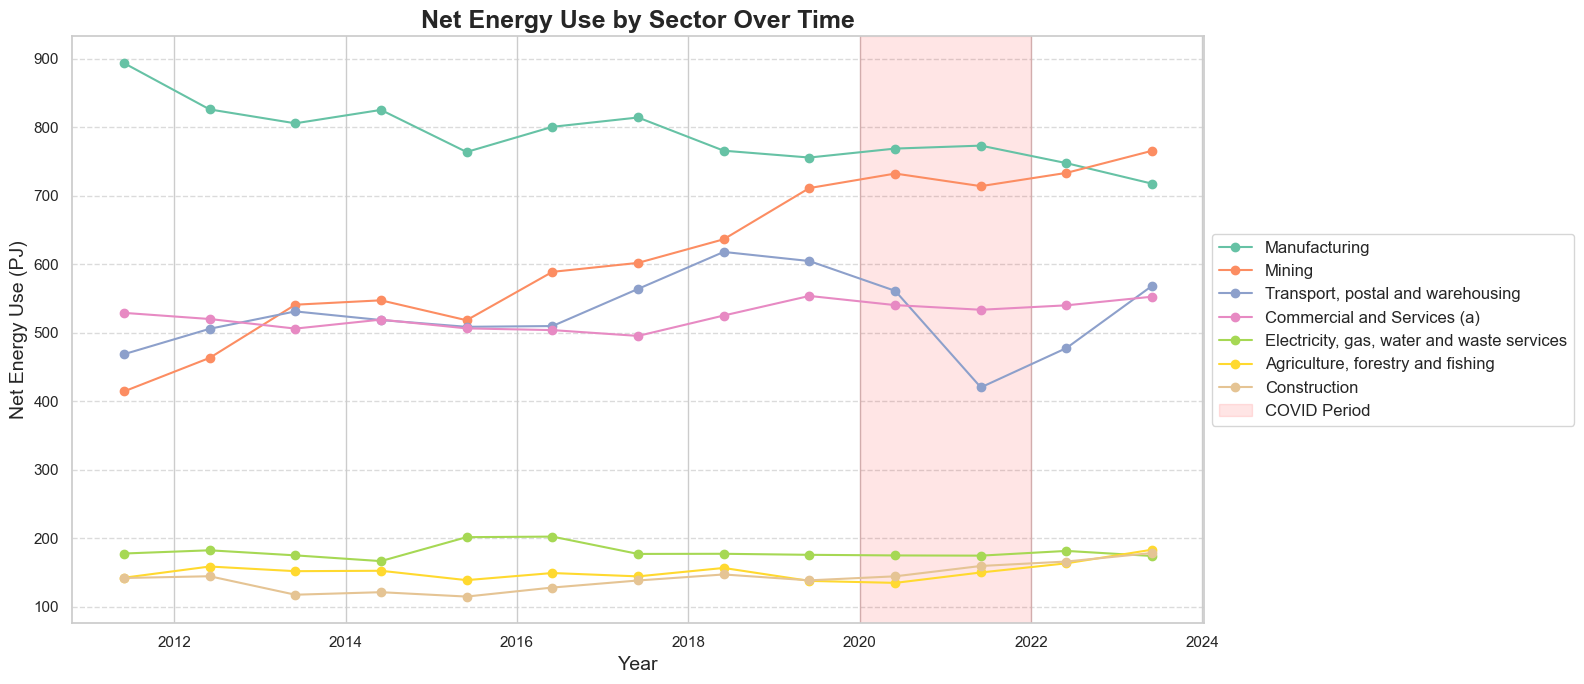

In [176]:
# let's look at energy use over time, by industry
columns_of_interest = [
    'Net Energy use - Agriculture, forestry and fishing',
    'Net Energy use - Mining',
    'Net Energy use - Manufacturing',
    'Net energy use - Electricity, gas, water and waste services',
    'Net Energy use - Construction',
    'Net Energy use - Transport, postal and warehousing ',
    'Net Energy use - Commercial and Services (a)',
]

# plot it
sns.set_theme(style="whitegrid", palette="colorblind")

# order the legend
columns_of_interest = sorted(columns_of_interest, key=lambda x: df_merged[x].mean(), reverse=True)

plt.figure(figsize=(16, 7))
palette = sns.color_palette("Set2", len(columns_of_interest))
for i, col in enumerate(columns_of_interest):
    label = col.replace('Net Energy use - ', '').replace('Net energy use - ', '').strip()
    plt.plot(df_merged.index, df_merged[col], label=label, linewidth=1.5, marker='o', color=palette[i])

plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), 
            color='red', alpha=0.1, label='COVID Period')
plt.title('Net Energy Use by Sector Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Net Energy Use (PJ)', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Energy Use By Sectory

Visually, we can already see 3 different groupings. And we can also see the gradual decline of Manufacturing and and moderate increase of Mining. 
Noting the dip, I also though it was relevant to add in the COVID period as it was instructive with transport taking the biggest hit to usage, and surprisingly manufacturing increasing ? 

This tells a story of sector usage, but it also tells a story of the Australian economy. 

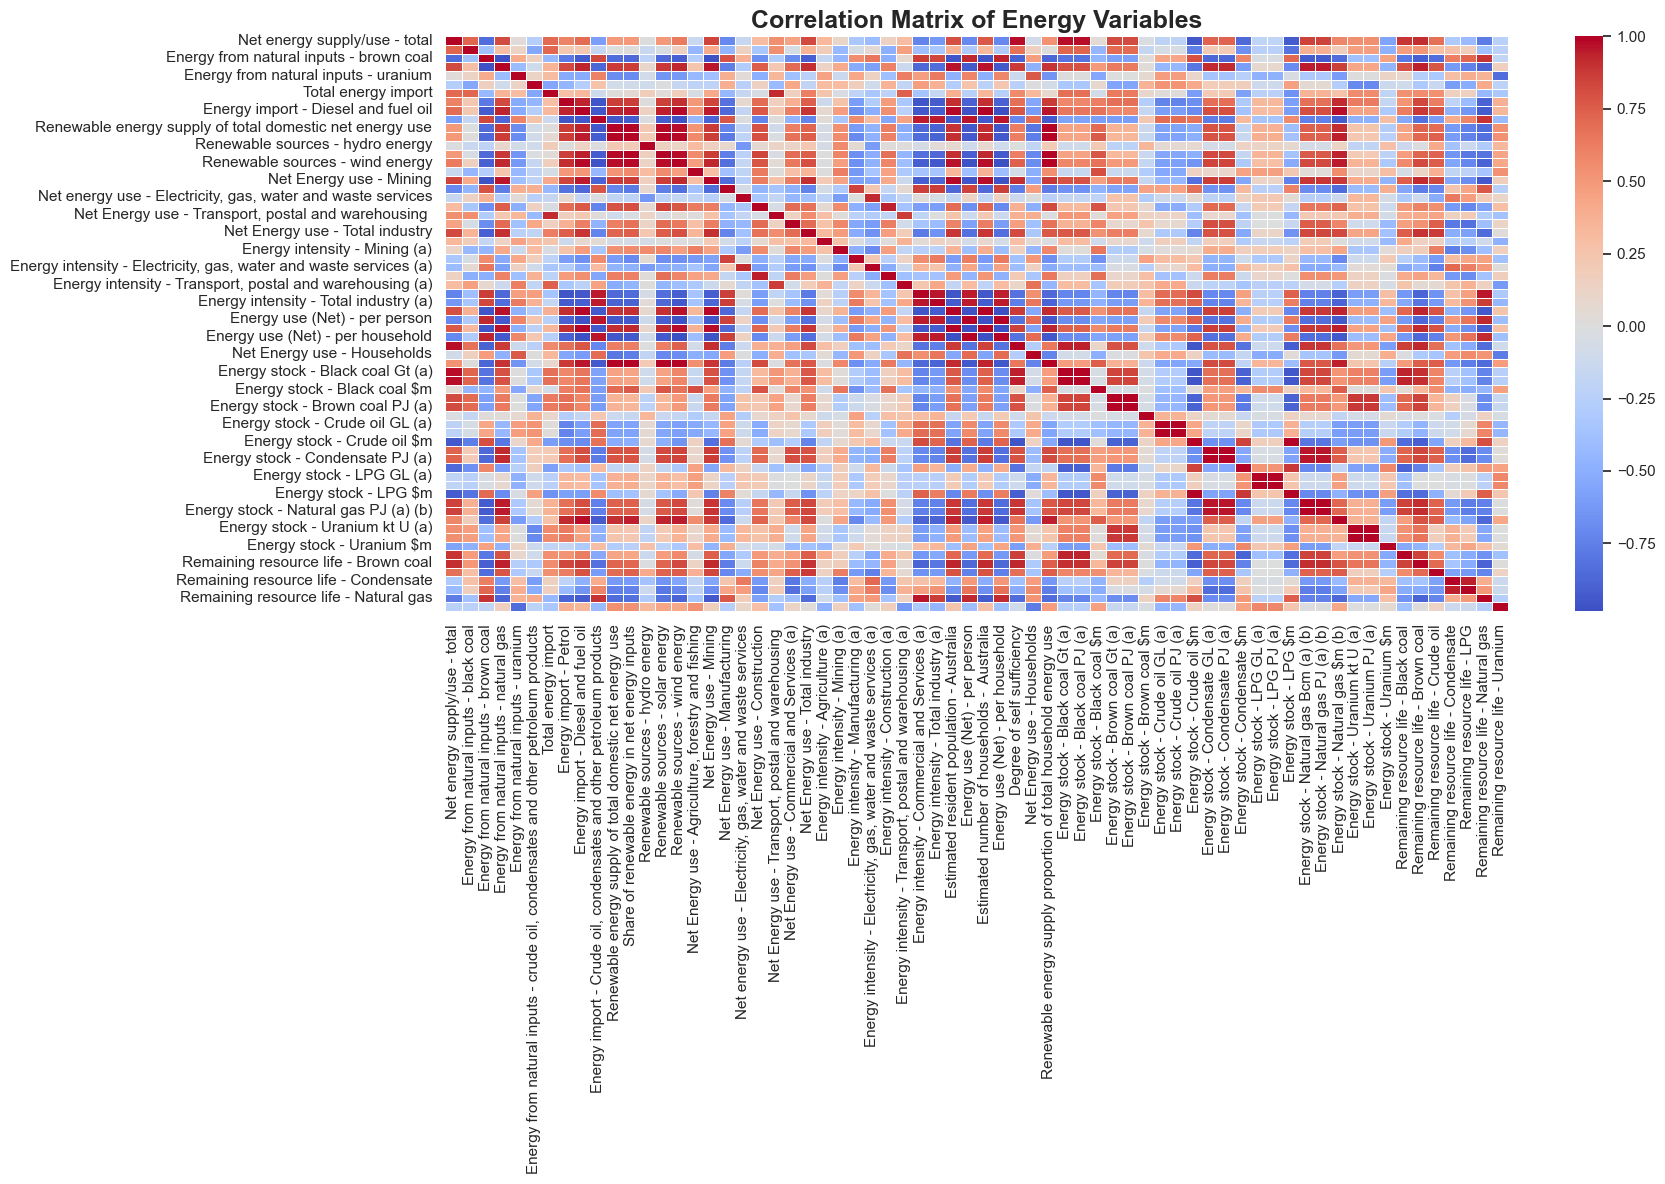

In [162]:
# let's see what this dataset has to offer
corr = df_merged.corr(numeric_only=True)
plt.figure(figsize=(18, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=.5)
plt.title('Correlation Matrix of Energy Variables', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


## That's a little much, isn't it ? 
It might seem a little much at first, but it is actually useful, first of all we can look at areas with deep red or blue to see their relationships. As I print them out below. First of all there will be a lot of obvious high correlations, but there are intersting relationships within as well. For example, start with the first row: Net Energy Use. You'll see it's correlated with energy usage in minning and inversely with energy usage in manufacturing. Reiterating that picture of an economy of decreasing importance on manufacturing. 

Given the difficulties however, we can also print out the top of each category. And pick one to dive deeper into. That's the purpose of this graph, to give us material to dive deeper on. 


In [163]:
corr_pairs = corr.unstack().dropna()
# Drop self-correlation and duplicate pairs
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.groupby([frozenset(x) for x in corr_pairs.index]).mean()

# Sort by correlation value
sorted_corr = corr_pairs.sort_values(ascending=False)

print("Top positive correlations:\n", sorted_corr.head(10))
print("\nTop negative correlations:\n", sorted_corr.tail(10))


Top positive correlations:
 (Energy stock - Condensate GL (a), Energy stock - Condensate PJ (a))                                                  1.000000
(Energy stock - Brown coal Gt (a), Energy stock - Brown coal PJ (a))                                                  1.000000
(Energy stock - Black coal Gt (a), Energy stock - Black coal PJ (a))                                                  1.000000
(Energy stock - Uranium kt U (a), Energy stock - Uranium PJ (a))                                                      1.000000
(Energy stock - Crude oil PJ (a), Energy stock - Crude oil GL (a))                                                    1.000000
(Energy stock - Natural gas Bcm (a) (b), Energy stock - Natural gas PJ (a) (b))                                       1.000000
(Energy stock - LPG PJ (a), Energy stock - LPG GL (a))                                                                1.000000
(Energy use (Net) - per person, Energy use (Net) - per household)                  

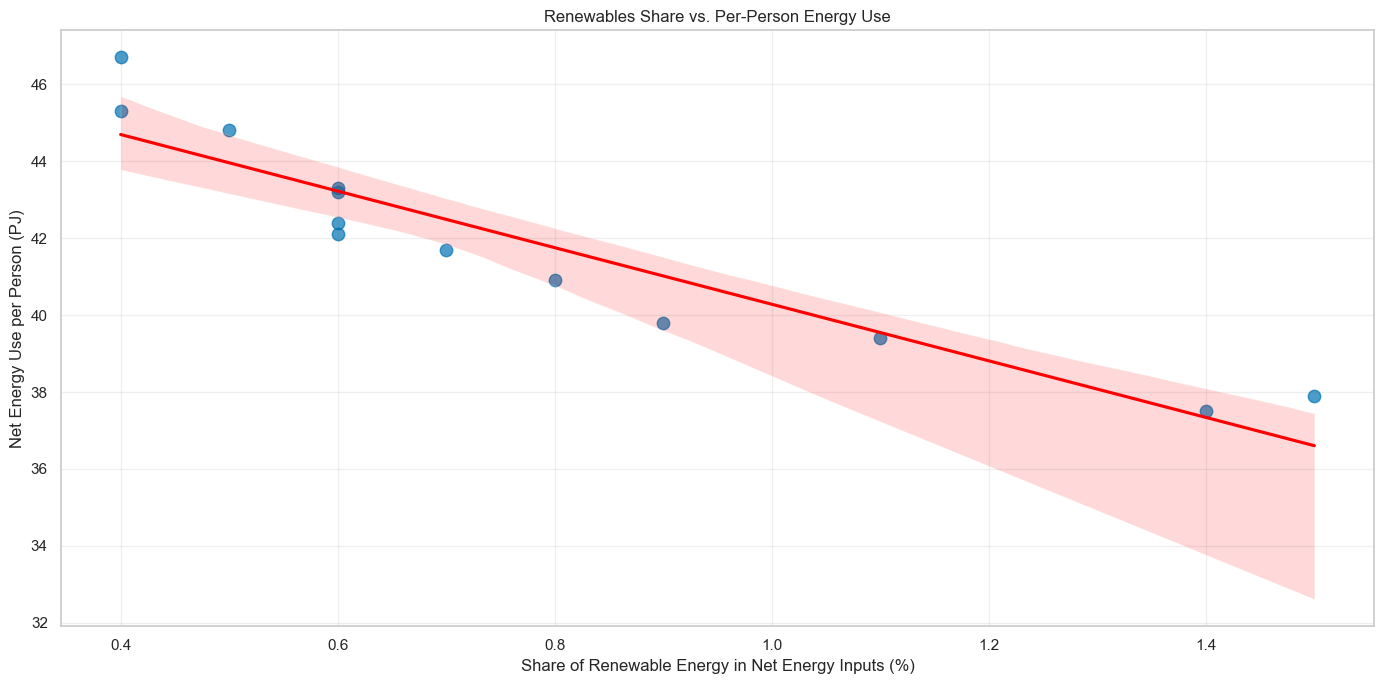

In [180]:
plt.figure(figsize=(14,7))
sns.regplot(
    x=df_merged['Share of renewable energy in net energy inputs'],
    y=df_merged['Energy use (Net) - per person'],
    scatter_kws={'s':80, 'alpha':0.7},
    line_kws={'color':'red'}
)
plt.xlabel('Share of Renewable Energy in Net Energy Inputs (%)')
plt.ylabel('Net Energy Use per Person (PJ)')
plt.title('Renewables Share vs. Per-Person Energy Use')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Renewables Share vs. Per-Person Energy Use

This scatter plot reveals a notable inverse relationship between renewable energy adoption and per-person energy consumption in Australia:

- As the share of renewable energy increases, per-person energy use tends to decrease
- The negative correlation suggests efficiency improvements may accompany renewable transitions
- The relationship isn't perfectly linear, with some outlier years showing different patterns

This trend could indicate that investments in renewable energy coincide with broader energy efficiency measures, or that the transition to renewables inherently drives more efficient energy use practices. It might also reflect changes in consumer behavior as awareness of energy sustainability grows.



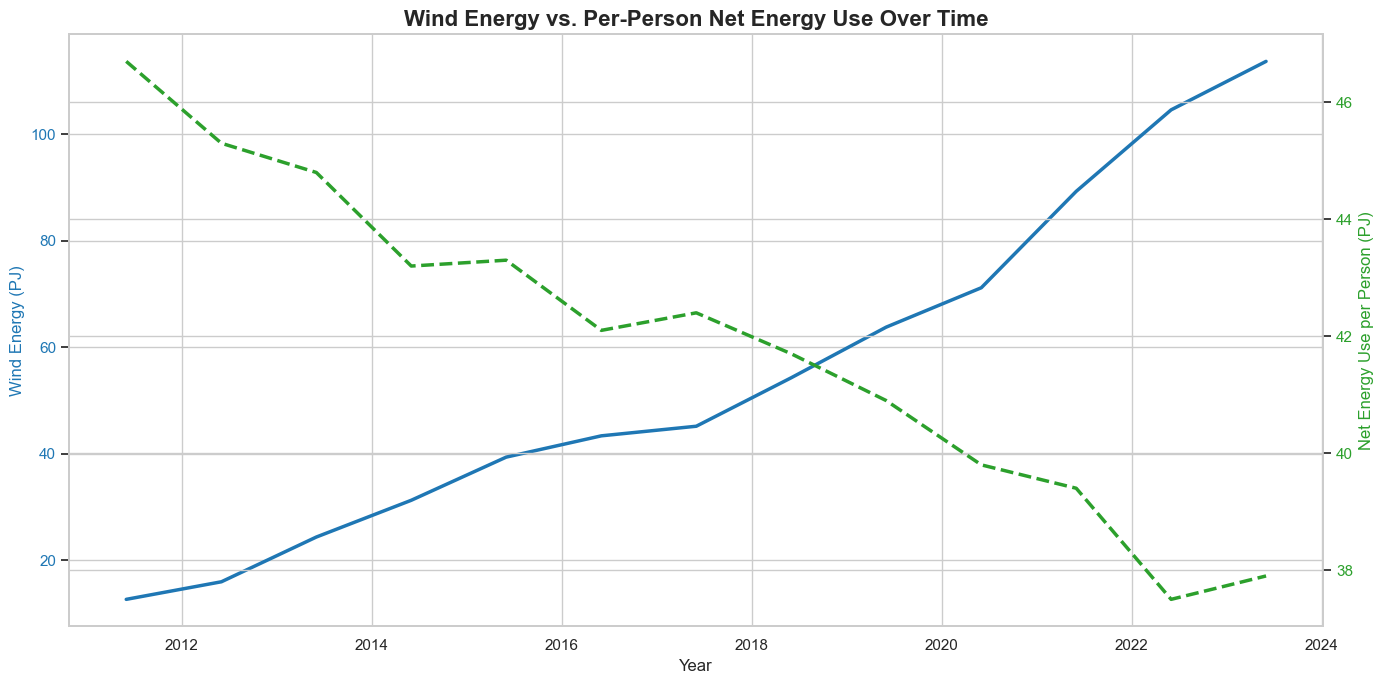

In [182]:
fig, ax1 = plt.subplots(figsize=(14,7))

color1 = 'tab:blue'
color2 = 'tab:green'

# First axis: Wind energy over time
ax1.set_xlabel('Year')
ax1.set_ylabel('Wind Energy (PJ)', color=color1)
ax1.plot(df_merged.index, df_merged['Renewable sources - wind energy'], color=color1, linewidth=2.5, label='Wind Energy')
ax1.tick_params(axis='y', labelcolor=color1)

# Second axis: Per person energy use over time
ax2 = ax1.twinx()
ax2.set_ylabel('Net Energy Use per Person (PJ)', color=color2)
ax2.plot(df_merged.index, df_merged['Energy use (Net) - per person'], color=color2, linewidth=2.5, linestyle='--', label='Per Person Use')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Wind Energy vs. Per-Person Net Energy Use Over Time', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()


## Wind Energy Growth vs. Per-Person Energy Trends

The dual-axis chart above illustrates two important energy trends in Australia:

- **Wind energy** (blue line) shows dramatic growth, particularly accelerating after 2010
- **Per-person energy use** (green dashed line) shows a gradual decline over the same period

This inverse relationship is particularly striking after 2010, when wind energy begins its steepest climb while per-person consumption begins a more pronounced decline. The divergence suggests that Australia's energy transition is successfully reducing individual energy footprints while increasing clean energy production.

## Conclusion: Australia's Energy Transformation

Our analysis of energy usage across Australian sectors reveals a complex transformation in progress:

1. **Sectoral Shifts**: Mining energy use is growing while manufacturing declines, reflecting Australia's economic evolution

2. **Efficiency Gains**: The inverse relationship between renewable adoption and per-person energy use indicates a more efficient energy future

3. **COVID Impact**: The pandemic created distinct but temporary disruptions across sectors, with transportation seeing the largest reduction

These patterns tell a story beyond just energy statistics - they provide insights into Australia's economic priorities, technological advancements, and progress toward sustainability goals. As wind and other renewable sources continue their rapid growth, Australia appears to be successfully decoupling energy consumption from economic growth.



## Source ? Petroleum statistics

---


In [34]:
# import the essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
file_path = 'australian-petroleum-statistics-data-extract-december-2024.xlsx'
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Available sheets:", sheet_names)

Available sheets: ['Index', 'Copyright ', 'Data sources and notes', 'Petroleum production', 'Petroleum production by basin', 'Refinery production', 'Sales of products', 'Sales by state and territory', 'Sales of lubricants', 'Imports volume', 'Imports value', 'Imports volume by country', 'Imports value by country', 'Exports volume', 'Exports value', 'Exports volume by country', 'Exports value by country', 'Destination of LNG exports', 'Stock volume by product', 'Stock mass by product', 'Consumption cover', 'IEA days net import cover', 'Stock volume incl. on the way', 'Stock IEA days incl. on the way', 'Australian fuel prices', 'OECD fuel prices and taxes']


# Australian Petroleum Production and Pricing Analysis

In this notebook, we'll analyze trends in Australian petroleum production and fuel prices using data from the Australian Government's petroleum statistics. 

The analysis will focus on two key aspects:
1. Production volumes of different petroleum products over time
2. Changes in retail fuel prices for major fuel types

These insights will help us understand Australia's energy production landscape and how fuel pricing has evolved in recent years.

In [75]:
# load a specific sheet
df1 = xls.parse('Petroleum production')

# lowercase the column names
df1.columns = (
    df1.columns
      .str.lower()
      .str.replace('[()]', '', regex=True)   # Remove all types of brackets
      .str.replace(' ', '_')
)

# last column not numeric
df1['lng_exports_mm3'] = pd.to_numeric(df1['lng_exports_mm3'], errors='coerce').fillna(0).astype('int64')

# load our next dataset
df2 = xls.parse('Australian fuel prices')

# lowercase the column names
df2.columns = (
    df2.columns
      .str.lower()
      .str.replace('[()]', '', regex=True)   # Remove all types of brackets
      .str.replace(' ', '_')
)

# map quarters to months
quarter_to_month = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}
df2['date'] = df2['year'].astype(str) + '-' + df2['quarter'].map(quarter_to_month) + '-01'

# set to datetime, set to index, remove old columns
df2['date'] = pd.to_datetime(df2['date'])
df2.set_index('date', inplace=True)
df2.drop(columns=['year', 'quarter'], inplace=True)

## Data Preparation

Before diving into analysis, we need to properly prepare our data. We've loaded two key datasets:

1. **Petroleum Production Data**: Contains monthly volumes of different petroleum products produced in Australia
2. **Australian Fuel Prices Data**: Contains quarterly price information for various fuel types

Our preparation steps include:
- Standardizing column names (lowercase, replacing spaces with underscores)
- Converting text-based dates to proper datetime format
- Setting appropriate index for time-series analysis
- Converting production volumes to numeric formats

This clean data structure will allow us to identify trends and patterns more effectively.

In [79]:
# check it
#df1.sample(6)
#df1.info()

df2.sample(6)
#df2.info()

,premium_unleaded_petrol_95_ron_cpl,regular_unleaded_petrol_91_ron_cpl,automotive_diesel_cpl,automotive_lpg_cpl
date,,,,
2023-10-01,212,196,209,96
2013-10-01,159,148,159,80
2018-07-01,159,148,154,80
2010-04-01,139,129,130,60
2012-10-01,153,142,150,75
2013-04-01,151,141,146,64


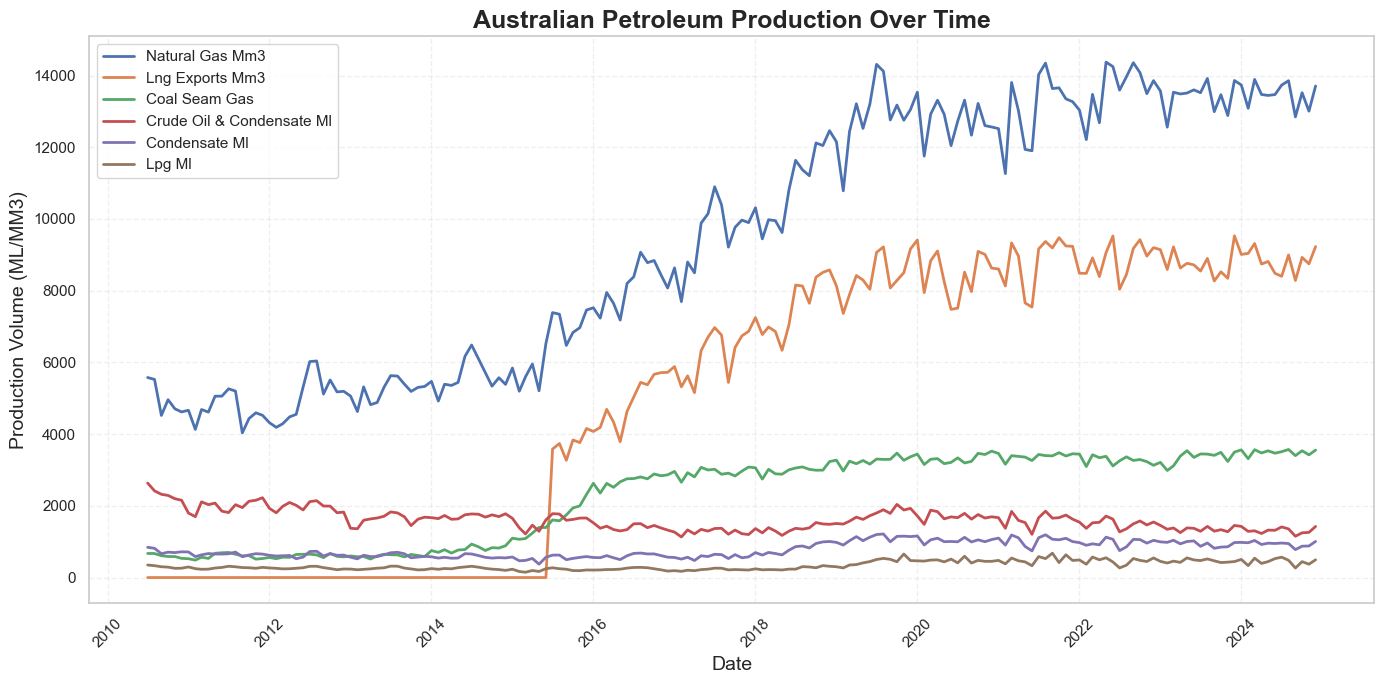

In [65]:
# plot pre-work
plt.figure(figsize=(14, 7))
palette = sns.color_palette("tab10", n_colors=len(df1.columns[2:]))
custom_labels = {'natural_gas,_of_which:_coal_seam_gas_mm3': 'Coal Seam Gas'}
value_cols = df1.columns[2:]
last_vals = df1[value_cols].iloc[-1].sort_values(ascending=False)

# plot actual
for col in last_vals.index:
    label = custom_labels.get(col, col.replace('_', ' ').title())
    plt.plot(df1['month'], df1[col], label=label, linewidth=2)
    
# tidying the plot
plt.title('Australian Petroleum Production Over Time', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Production Volume (ML/MM3)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Petroleum Production Trends

The line graph above illustrates several important trends in Australian petroleum production:

1. **Diverse Production Mix**: Australia produces a variety of petroleum products, including natural gas, LPG, and various refined products.

2. **Coal Seam Gas Growth**: There has been significant growth in coal seam gas production, highlighting Australia's shift toward unconventional gas resources.

3. **Production Volatility**: Several products show considerable month-to-month volatility, which may reflect maintenance shutdowns, seasonal demand patterns, or market fluctuations.

4. **Long-term Trends**: Some products show clear upward or downward trends over time, indicating structural changes in Australia's energy production landscape.

These production patterns are critical to understanding Australia's energy security and export potential, particularly as global markets increasingly focus on cleaner energy sources.

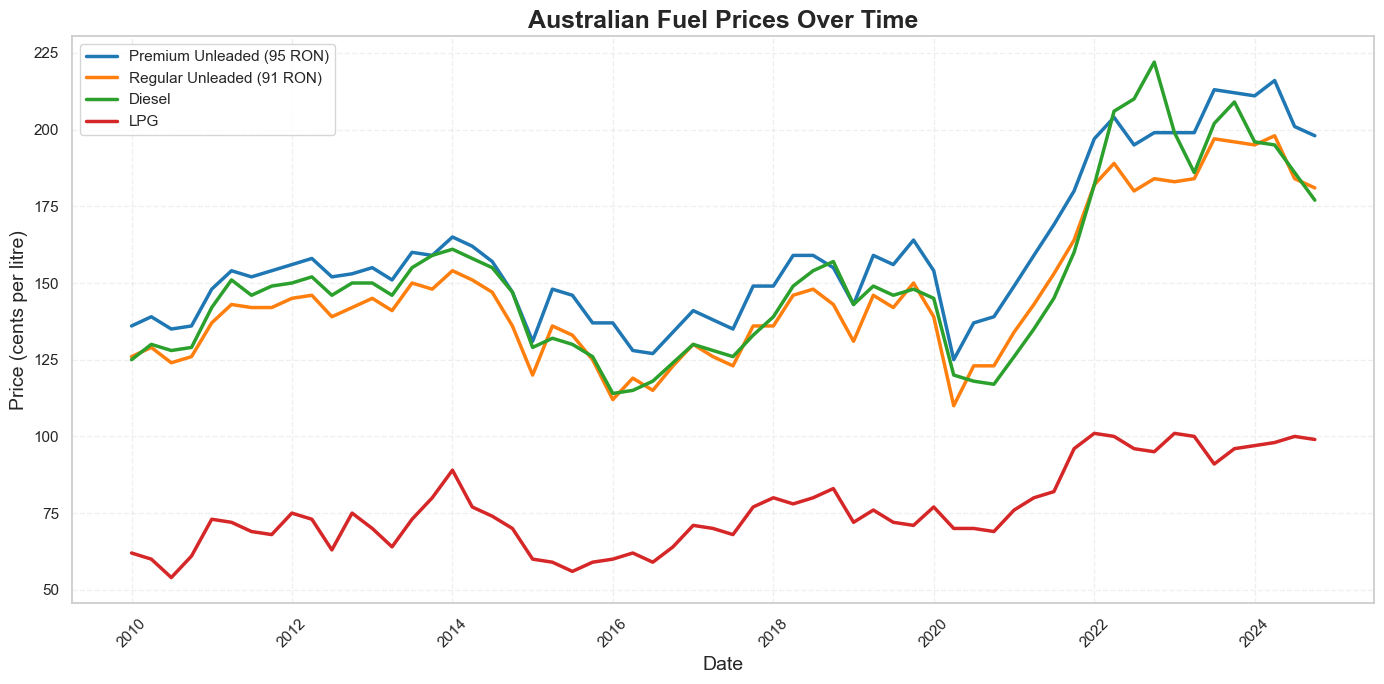

In [82]:
plt.figure(figsize=(14, 7))
palette = sns.color_palette("tab10", n_colors=len(df2.columns))

# Only fuel columns (all except the index)
value_cols = df2.columns

# Get last (most recent) values for ordering
last_vals = df2[value_cols].iloc[-1].sort_values(ascending=False)

# Optional: custom labels for legend
custom_labels = {
    'premium_unleaded_petrol_95_ron_cpl': 'Premium Unleaded (95 RON)',
    'regular_unleaded_petrol_91_ron_cpl': 'Regular Unleaded (91 RON)',
    'automotive_diesel_cpl': 'Diesel',
    'automotive_lpg_cpl': 'LPG'
}

# Plot each line in order of their most recent value (descending)
for idx, col in enumerate(last_vals.index):
    label = custom_labels.get(col, col.replace('_', ' ').title())
    plt.plot(df2.index, df2[col], label=label, linewidth=2.5, color=palette[idx])

plt.title('Australian Fuel Prices Over Time', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (cents per litre)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Australian Fuel Price Trends

The visualization of Australian fuel prices reveals several significant patterns:

1. **Price Hierarchy**: Premium fuels consistently command higher prices than regular unleaded, with diesel typically positioned between premium and regular unleaded prices.

2. **Synchronized Movements**: All fuel types tend to move in the same direction simultaneously, indicating common underlying factors like global oil prices affecting the entire market.

3. **Increasing Volatility**: Recent years show more pronounced price fluctuations compared to earlier periods, suggesting increased market sensitivity and uncertainty.

4. **Long-term Price Increases**: Despite short-term fluctuations, the overall trend shows fuel prices rising over time, outpacing general inflation.

5. **COVID-19 Impact**: A notable price drop is visible during the early COVID-19 pandemic period (2020), reflecting collapsed global demand, followed by a strong recovery as economies reopened.

## Conclusions: Australia's Petroleum Landscape

Our analysis of Australian petroleum production and pricing data highlights several important insights:

1. **Production Diversification**: Australia maintains a diverse petroleum production portfolio, with increasing emphasis on natural gas resources, particularly coal seam gas.

2. **Price Pressure on Consumers**: The consistent upward trajectory of fuel prices, punctuated by periods of high volatility, creates ongoing cost pressures for Australian consumers and businesses.

3. **Global Market Integration**: The synchronization of price movements across different fuel types demonstrates Australia's deep integration with global energy markets.

4. **Energy Transition Considerations**: The production trends, particularly in gas, highlight Australia's positioning in the global energy transition - balancing traditional fossil fuel production with growing awareness of climate considerations.

These patterns underscore the complex balancing act Australia faces between energy security, economic considerations, and environmental objectives in its petroleum sector.

## Original sources

- [National energy overview](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day01/intro_ausenergy.ipynb)
- [Energy tables and fuel mix](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day02/aus_energy_part2.ipynb)
- [State-by-state energy](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day03/aus_energy_states.ipynb)
- [Energy use by sector](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day04/energy_usage_aus.ipynb)
- [Petroleum statistics](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day05/aus_petorleum_stats.ipynb)